# 迴歸分析基礎 - ML 面試準備

本筆記本涵蓋迴歸分析的核心概念與實作技巧，專為 ML 面試準備設計。

**涵蓋主題：**
- 線性迴歸理論基礎與數學推導
- 模型假設檢驗與診斷
- 特徵工程與異常值處理
- 面試常見問題與解答

**注意：** 正則化技術（Ridge、Lasso、ElasticNet）的詳細內容請參考 `linear_regression.ipynb`。

---
# Part 1: 理論基礎
---

## 1.1 迴歸概述

### 什麼是迴歸？

**迴歸分析**是一種統計方法，用於建立自變數（特徵）與連續型應變數（目標）之間的關係模型。

### 迴歸 vs 分類

| 面向 | 迴歸 | 分類 |
|------|------|------|
| 目標變數 | 連續值（如房價、溫度） | 離散類別（如是/否、A/B/C） |
| 輸出範圍 | 實數範圍 | 固定類別集合 |
| 評估指標 | MSE、RMSE、MAE、R² | Accuracy、Precision、Recall、F1 |
| 常見演算法 | 線性迴歸、Ridge、SVR | 邏輯迴歸、決策樹、SVM |

### 迴歸類型

| 類型 | 描述 | 使用時機 |
|------|------|----------|
| **簡單線性迴歸** | 一個自變數 | 探索單一特徵影響 |
| **多元線性迴歸** | 多個自變數 | 實際建模場景 |
| **多項式迴歸** | 加入高次項 | 非線性關係 |
| **正則化迴歸** | 加入懲罰項 | 防止過擬合、特徵選擇 |

## 1.2 簡單線性迴歸

### 數學模型

簡單線性迴歸假設目標變數 $y$ 與單一特徵 $x$ 之間存在線性關係：

$$y = \beta_0 + \beta_1 x + \epsilon$$

其中：
- $\beta_0$：截距（intercept），當 $x=0$ 時的 $y$ 值
- $\beta_1$：斜率（slope），$x$ 每增加一單位，$y$ 的預期變化量
- $\epsilon$：誤差項，假設 $\epsilon \sim N(0, \sigma^2)$

### OLS 推導（最小平方法）

**目標**：最小化殘差平方和（RSS）

$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

**對 $\beta_0$ 和 $\beta_1$ 求偏導並令其為 0：**

$$\frac{\partial RSS}{\partial \beta_0} = -2\sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i) = 0$$

$$\frac{\partial RSS}{\partial \beta_1} = -2\sum_{i=1}^{n}x_i(y_i - \beta_0 - \beta_1 x_i) = 0$$

**解得：**

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = \frac{Cov(x,y)}{Var(x)}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### 係數解釋

- **$\beta_1 > 0$**：正相關，$x$ 增加時 $y$ 也增加
- **$\beta_1 < 0$**：負相關，$x$ 增加時 $y$ 減少
- **$\beta_1 = 0$**：無線性關係

## 1.3 多元線性迴歸

### 多變數模型

當有多個特徵時，模型擴展為：

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p + \epsilon$$

### 矩陣表示

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

其中：
- $\mathbf{y}$：$n \times 1$ 目標向量
- $\mathbf{X}$：$n \times (p+1)$ 設計矩陣（含截距項的 1）
- $\boldsymbol{\beta}$：$(p+1) \times 1$ 係數向量
- $\boldsymbol{\epsilon}$：$n \times 1$ 誤差向量

$$\mathbf{X} = \begin{bmatrix} 1 & x_{11} & x_{12} & \cdots & x_{1p} \\ 1 & x_{21} & x_{22} & \cdots & x_{2p} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \cdots & x_{np} \end{bmatrix}$$

### 正規方程式（Normal Equation）

OLS 解的矩陣形式：

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

**優點：**
- 直接得到精確解
- 不需調整學習率

**缺點：**
- 計算複雜度 $O(p^3)$
- 當 $\mathbf{X}^T\mathbf{X}$ 不可逆時失效（多重共線性）
- 不適合大規模資料集

## 1.4 模型假設（LINE）

線性迴歸的有效性依賴於四個關鍵假設，可用 **LINE** 記憶：

### L - Linearity（線性）

**假設內容：** 自變數與應變數之間存在線性關係。

**檢驗方法：**
- 殘差 vs 預測值散佈圖（應呈隨機分布）
- 偏殘差圖（Partial residual plot）

**違反後果：**
- 係數估計有偏誤
- 預測不準確

**解決方法：**
- 加入多項式項
- 對變數進行轉換（對數、平方根等）
- 使用非線性模型

---

### I - Independence（獨立性）

**假設內容：** 觀測值之間相互獨立，殘差之間無自相關。

**檢驗方法：**
- Durbin-Watson 檢定（DW 值接近 2 表示無自相關）
- 殘差自相關圖（ACF plot）

**違反後果：**
- 標準誤估計不準確
- 假設檢定和信賴區間無效

**常見於：** 時間序列資料、空間資料

**解決方法：**
- 加入滯後項
- 使用時間序列模型（ARIMA）
- Generalized Least Squares (GLS)

---

### N - Normality（常態性）

**假設內容：** 殘差服從常態分布 $\epsilon \sim N(0, \sigma^2)$。

**檢驗方法：**
- Q-Q plot（點應落在對角線上）
- Shapiro-Wilk 檢定
- 殘差直方圖

**違反後果：**
- 係數估計仍無偏，但 t 檢定和 F 檢定不準確
- 信賴區間和預測區間無效

**解決方法：**
- 對目標變數進行轉換（Box-Cox）
- 移除極端異常值
- 大樣本下中央極限定理可緩解

---

### E - Equal Variance（等變異數 / Homoscedasticity）

**假設內容：** 殘差的變異數在所有預測值水準上保持恆定。

**檢驗方法：**
- 殘差 vs 預測值圖（應呈均勻寬度的帶狀）
- Breusch-Pagan 檢定
- White 檢定

**違反情況（Heteroscedasticity）：**
- 殘差呈現漏斗狀或扇形

**違反後果：**
- 係數估計仍無偏，但不再是最佳估計
- 標準誤估計不準確

**解決方法：**
- 對目標變數取對數
- 加權最小平方法（WLS）
- 使用穩健標準誤（Robust standard errors）

## 1.5 評估指標

### 常用指標一覽

| 指標 | 公式 | 特性 |
|------|------|------|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | 對大誤差敏感，可微分 |
| **RMSE** | $\sqrt{MSE}$ | 與目標同單位，直觀 |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | 對異常值較穩健 |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | 解釋變異比例，0-1 範圍 |
| **Adjusted R²** | $1 - \frac{(1-R^2)(n-1)}{n-p-1}$ | 考慮特徵數量的懲罰 |

### MSE vs MAE 選擇

| 情境 | 建議使用 | 原因 |
|------|----------|------|
| 大誤差代價高 | MSE/RMSE | 平方懲罰大誤差 |
| 存在異常值 | MAE | 對極端值更穩健 |
| 需要可微分 | MSE | 梯度下降優化 |
| 業務解釋 | MAE | 平均絕對誤差更直觀 |

### R² vs Adjusted R²

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

$$Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$

**R² 的問題：** 加入任何特徵（即使無關）都會使 R² 增加。

**Adjusted R² 優點：** 對特徵數量進行懲罰，更適合比較不同特徵數量的模型。

## 1.6 多重共線性

### 定義

**多重共線性（Multicollinearity）** 指自變數之間存在高度線性相關。

### 問題影響

| 影響 | 說明 |
|------|------|
| 係數不穩定 | 小幅資料變動導致係數大幅改變 |
| 標準誤膨脹 | 難以判斷個別特徵的顯著性 |
| 矩陣近似奇異 | $(X^TX)^{-1}$ 計算不穩定 |
| 解釋困難 | 無法分離個別特徵的影響 |

**注意：** 多重共線性不影響預測能力，但嚴重影響係數解釋。

### VIF（Variance Inflation Factor）

$$VIF_j = \frac{1}{1 - R_j^2}$$

其中 $R_j^2$ 是以第 $j$ 個特徵為目標，其他特徵為自變數的迴歸 R²。

| VIF 值 | 解釋 |
|--------|------|
| 1 | 無共線性 |
| 1-5 | 低度共線性（通常可接受） |
| 5-10 | 中度共線性（需注意） |
| > 10 | 高度共線性（需處理） |

### 處理方法

1. **移除相關特徵**：保留業務上更重要的那個
2. **主成分分析（PCA）**：轉換為不相關的主成分
3. **正則化**：Ridge 迴歸能有效處理共線性
4. **特徵組合**：將相關特徵合併（如加總、平均）

---
# Part 2: 實作 - 基礎建模
---

## 2.1 環境設定

In [12]:
# 核心套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn 模組
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 統計檢定
from scipy import stats
from scipy.stats import shapiro, normaltest

# 設定
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# 中文字體設定 (macOS)
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("環境設定完成！")

環境設定完成！


## 2.2 資料載入與 EDA

使用 California Housing 資料集：
- 20,640 筆資料，8 個特徵
- 目標：房屋中位數價格（以 10 萬美元為單位）
- sklearn 內建，無需額外下載

In [13]:
# 載入資料（使用 OpenML 作為資料來源）
# OpenML 的 'houses' 資料集與 sklearn.fetch_california_housing 相同來源
california = fetch_openml(name='houses', version=1, as_frame=True, parser='auto')
print("從 OpenML 成功載入 California Housing 資料集")

# 轉換特徵以匹配 sklearn.fetch_california_housing 格式
# sklearn 版本的 AveRooms, AveBedrms, AveOccup 是 per-household 的平均值
df = pd.DataFrame({
    'MedInc': california.data['median_income'],
    'HouseAge': california.data['housing_median_age'],
    'AveRooms': california.data['total_rooms'] / california.data['households'],
    'AveBedrms': california.data['total_bedrooms'] / california.data['households'],
    'Population': california.data['population'],
    'AveOccup': california.data['population'] / california.data['households'],
    'Latitude': california.data['latitude'],
    'Longitude': california.data['longitude'],
    'MedHouseVal': california.target / 100000  # 轉換為 $100k 單位
})

print(f"\n資料集資訊：")
print(f"樣本數：{df.shape[0]:,}")
print(f"特徵數：{df.shape[1] - 1}")
print(f"\n特徵說明：")
for name, desc in zip(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], [
    "區塊內房屋的中位數收入",
    "區塊內房屋的中位數屋齡",
    "平均房間數",
    "平均臥室數",
    "區塊人口",
    "平均家庭成員數",
    "緯度",
    "經度"
]):
    print(f"  {name}: {desc}")

df.head()

從 OpenML 成功載入 California Housing 資料集

資料集資訊：
樣本數：20,640
特徵數：8

特徵說明：
  MedInc: 區塊內房屋的中位數收入
  HouseAge: 區塊內房屋的中位數屋齡
  AveRooms: 平均房間數
  AveBedrms: 平均臥室數
  Population: 區塊人口
  AveOccup: 平均家庭成員數
  Latitude: 緯度
  Longitude: 經度


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [14]:
# 基本統計
print("=" * 60)
print("基本統計量")
print("=" * 60)
df.describe().round(2)

基本統計量


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [15]:
# 缺失值檢查
print("缺失值檢查：")
print(df.isnull().sum())
print(f"\n總缺失值：{df.isnull().sum().sum()}")

缺失值檢查：
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

總缺失值：0


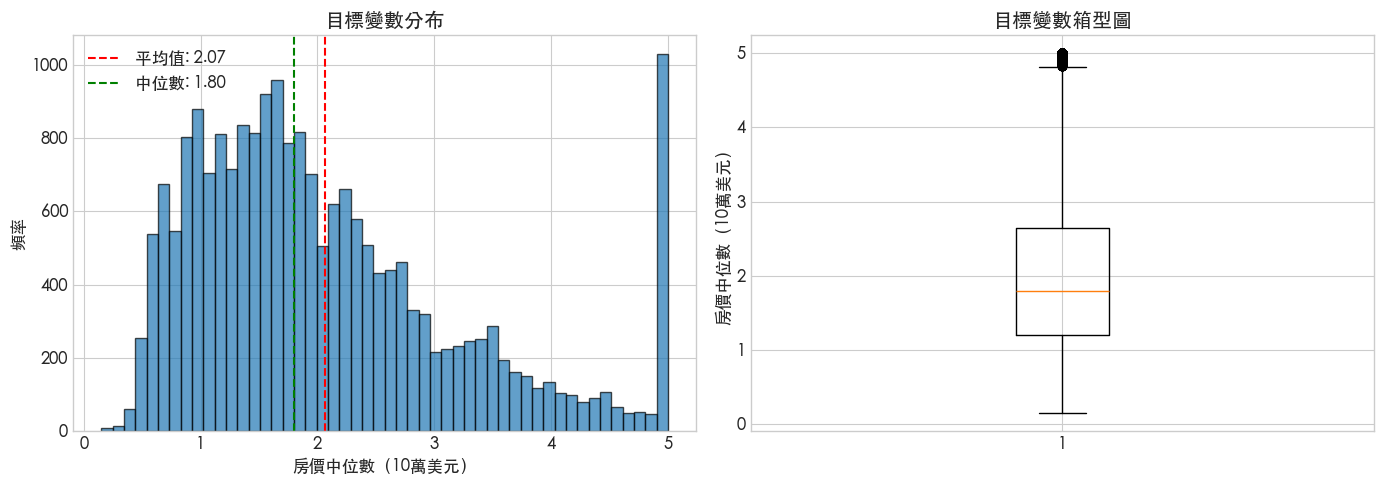

注意：目標值在 5.0 處有截斷（最大值限制）


In [16]:
# 目標變數分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方圖
axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', 
                label=f"平均值: {df['MedHouseVal'].mean():.2f}")
axes[0].axvline(df['MedHouseVal'].median(), color='green', linestyle='--',
                label=f"中位數: {df['MedHouseVal'].median():.2f}")
axes[0].set_xlabel('房價中位數（10萬美元）')
axes[0].set_ylabel('頻率')
axes[0].set_title('目標變數分布')
axes[0].legend()

# 箱型圖
axes[1].boxplot(df['MedHouseVal'], vert=True)
axes[1].set_ylabel('房價中位數（10萬美元）')
axes[1].set_title('目標變數箱型圖')

plt.tight_layout()
plt.show()

print(f"注意：目標值在 5.0 處有截斷（最大值限制）")

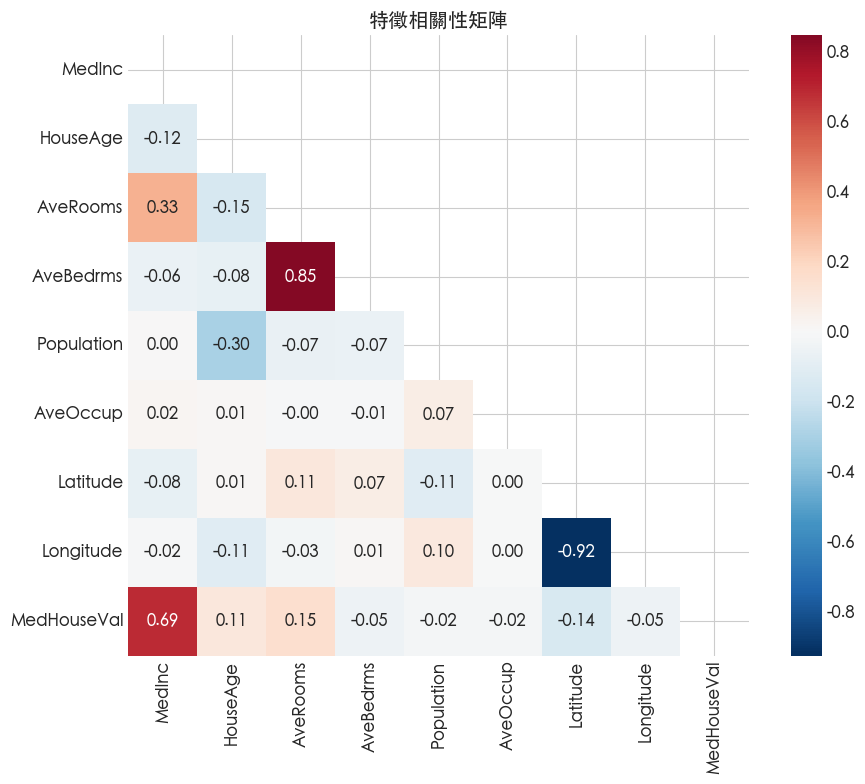


與目標變數 (MedHouseVal) 的相關性：
  MedInc: 0.688
  AveRooms: 0.152
  Latitude: -0.144
  HouseAge: 0.106
  AveBedrms: -0.047
  Longitude: -0.046
  Population: -0.025
  AveOccup: -0.024


In [17]:
# 相關性矩陣
plt.figure(figsize=(10, 8))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0,
            mask=mask, square=True, fmt='.2f')
plt.title('特徵相關性矩陣')
plt.tight_layout()
plt.show()

# 與目標變數的相關性排序
print("\n與目標變數 (MedHouseVal) 的相關性：")
target_corr = correlation['MedHouseVal'].drop('MedHouseVal').sort_values(key=abs, ascending=False)
for feature, corr in target_corr.items():
    print(f"  {feature}: {corr:.3f}")

## 2.3 資料前處理

In [18]:
# 特徵與目標分離
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 訓練/測試切分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"訓練集大小：{X_train.shape[0]:,} 筆")
print(f"測試集大小：{X_test.shape[0]:,} 筆")
print(f"特徵數：{X_train.shape[1]}")

訓練集大小：16,512 筆
測試集大小：4,128 筆
特徵數：8


In [19]:
# 特徵標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 轉為 DataFrame 保留欄位名稱
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("標準化後的統計量（訓練集）：")
print(f"平均值：{X_train_scaled.mean(axis=0).round(2)}")
print(f"標準差：{X_train_scaled.std(axis=0).round(2)}")

標準化後的統計量（訓練集）：
平均值：[-0. -0.  0. -0.  0.  0.  0.  0.]
標準差：[1. 1. 1. 1. 1. 1. 1. 1.]


## 2.4 簡單線性迴歸

先以單一特徵（MedInc，與目標相關性最高）建立簡單線性迴歸模型。

In [20]:
# 簡單線性迴歸：MedInc vs MedHouseVal
X_simple = X_train[['MedInc']].values
X_simple_test = X_test[['MedInc']].values

# 訓練模型
simple_lr = LinearRegression()
simple_lr.fit(X_simple, y_train)

# 預測
y_train_pred_simple = simple_lr.predict(X_simple)
y_test_pred_simple = simple_lr.predict(X_simple_test)

# 結果
print("簡單線性迴歸結果（MedInc）")
print("=" * 40)
print(f"截距 (β₀): {simple_lr.intercept_:.4f}")
print(f"斜率 (β₁): {simple_lr.coef_[0]:.4f}")
print(f"\n模型方程式：MedHouseVal = {simple_lr.intercept_:.4f} + {simple_lr.coef_[0]:.4f} × MedInc")
print(f"\n解釋：MedInc 每增加 1 單位，房價中位數預期增加 {simple_lr.coef_[0]:.4f} 個單位（10萬美元）")
print(f"        即約 {simple_lr.coef_[0] * 10:.2f} 萬美元（${simple_lr.coef_[0] * 100000:,.0f}）")

簡單線性迴歸結果（MedInc）
截距 (β₀): 0.4446
斜率 (β₁): 0.4193

模型方程式：MedHouseVal = 0.4446 + 0.4193 × MedInc

解釋：MedInc 每增加 1 單位，房價中位數預期增加 0.4193 個單位（10萬美元）
        即約 4.19 萬美元（$41,934）


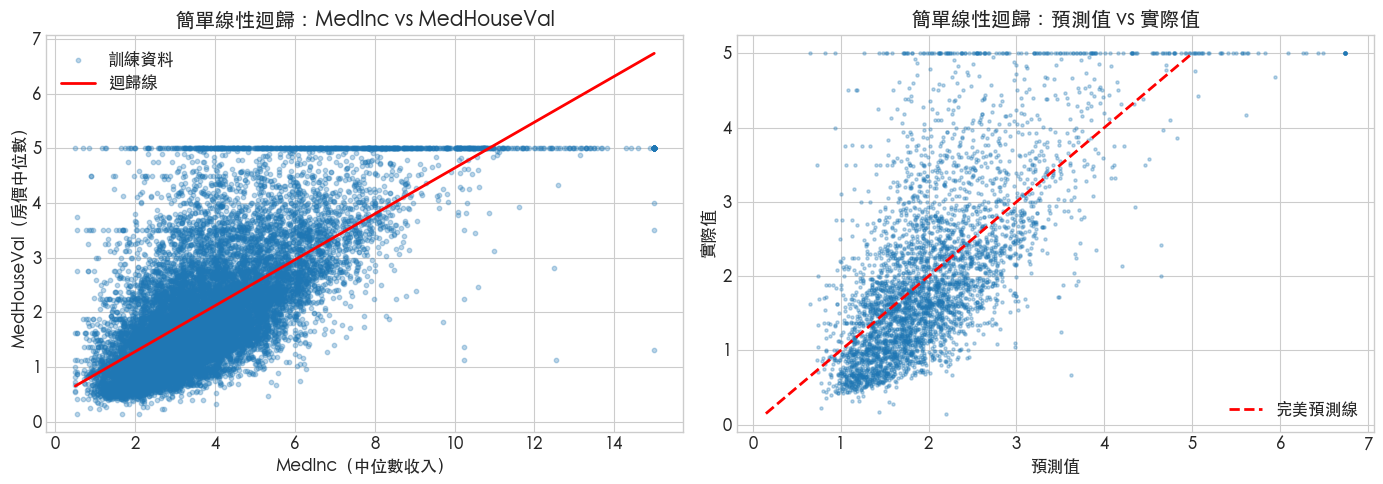


評估指標：
訓練集 R²: 0.4770
測試集 R²: 0.4589
測試集 RMSE: 0.8421


In [22]:
# 簡單線性迴歸視覺化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散佈圖與迴歸線
axes[0].scatter(X_simple, y_train, alpha=0.3, s=10, label='訓練資料')
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = simple_lr.predict(x_line)
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='迴歸線')
axes[0].set_xlabel('MedInc（中位數收入）')
axes[0].set_ylabel('MedHouseVal（房價中位數）')
axes[0].set_title('簡單線性迴歸：MedInc vs MedHouseVal')
axes[0].legend()

# 預測值 vs 實際值
axes[1].scatter(y_test_pred_simple, y_test, alpha=0.3, s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='完美預測線')
axes[1].set_xlabel('預測值')
axes[1].set_ylabel('實際值')
axes[1].set_title('簡單線性迴歸：預測值 vs 實際值')
axes[1].legend()

plt.tight_layout()
plt.show()

# 評估指標
print("\n評估指標：")
print(f"訓練集 R²: {r2_score(y_train, y_train_pred_simple):.4f}")
print(f"測試集 R²: {r2_score(y_test, y_test_pred_simple):.4f}")
print(f"測試集 RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_simple)):.4f}")

## 2.5 多元線性迴歸

使用所有特徵建立完整的多元線性迴歸模型。

In [23]:
# 多元線性迴歸（使用標準化資料）
multi_lr = LinearRegression()
multi_lr.fit(X_train_scaled, y_train)

# 預測
y_train_pred = multi_lr.predict(X_train_scaled)
y_test_pred = multi_lr.predict(X_test_scaled)

# 係數
print("多元線性迴歸結果")
print("=" * 50)
print(f"截距：{multi_lr.intercept_:.4f}")
print(f"\n標準化係數（可直接比較特徵重要性）：")
coef_df = pd.DataFrame({
    '特徵': X.columns,
    '係數': multi_lr.coef_
}).sort_values('係數', key=abs, ascending=False)

for _, row in coef_df.iterrows():
    direction = "正向" if row['係數'] > 0 else "負向"
    print(f"  {row['特徵']:15} : {row['係數']:8.4f} ({direction}影響)")

多元線性迴歸結果
截距：2.0719

標準化係數（可直接比較特徵重要性）：
  Latitude        :  -0.8969 (負向影響)
  Longitude       :  -0.8698 (負向影響)
  MedInc          :   0.8544 (正向影響)
  AveBedrms       :   0.3393 (正向影響)
  AveRooms        :  -0.2944 (負向影響)
  HouseAge        :   0.1225 (正向影響)
  AveOccup        :  -0.0408 (負向影響)
  Population      :  -0.0023 (負向影響)


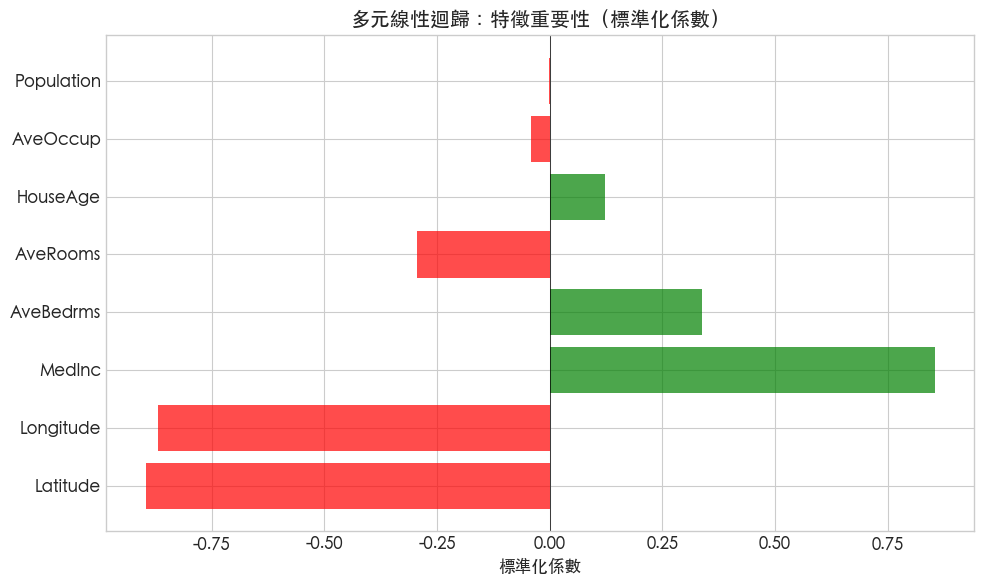

In [24]:
# 係數視覺化
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['係數']]
plt.barh(coef_df['特徵'], coef_df['係數'], color=colors, alpha=0.7)
plt.xlabel('標準化係數')
plt.title('多元線性迴歸：特徵重要性（標準化係數）')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [25]:
# 評估指標比較
def evaluate_regression(y_true, y_pred, dataset_name):
    """計算迴歸評估指標"""
    n = len(y_true)
    p = X_train.shape[1]
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return {
        '資料集': dataset_name,
        'R²': r2,
        'Adjusted R²': adj_r2,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

# 計算指標
train_metrics = evaluate_regression(y_train, y_train_pred, '訓練集')
test_metrics = evaluate_regression(y_test, y_test_pred, '測試集')

metrics_df = pd.DataFrame([train_metrics, test_metrics])
print("多元線性迴歸評估指標：")
print(metrics_df.to_string(index=False))

print(f"\n與簡單線性迴歸比較：")
print(f"簡單迴歸測試 R²: {r2_score(y_test, y_test_pred_simple):.4f}")
print(f"多元迴歸測試 R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"改進幅度: {(r2_score(y_test, y_test_pred) - r2_score(y_test, y_test_pred_simple)):.4f}")

多元線性迴歸評估指標：
資料集       R²  Adjusted R²     RMSE      MAE
訓練集 0.612551     0.612363 0.719676 0.528628
測試集 0.575788     0.574964 0.745581 0.533200

與簡單線性迴歸比較：
簡單迴歸測試 R²: 0.4589
多元迴歸測試 R²: 0.5758
改進幅度: 0.1169


## 2.6 假設檢驗實作

對多元線性迴歸模型進行 LINE 假設的完整檢驗。

In [26]:
# 計算殘差
residuals = y_train - y_train_pred
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

print(f"殘差統計量：")
print(f"  平均值：{residuals.mean():.6f}（應接近 0）")
print(f"  標準差：{residuals.std():.4f}")
print(f"  最小值：{residuals.min():.4f}")
print(f"  最大值：{residuals.max():.4f}")

殘差統計量：
  平均值：0.000000（應接近 0）
  標準差：0.7197
  最小值：-5.9348
  最大值：4.1807


KeyError: '[12154, 2300, 12571, 4590, 11782, 7453, 13553, 11793, 2701, 14425, 12136, 6541, 9102, 13443, 5436, 4328, 5687, 285, 8380, 13897, 9806, 2767, 8327, 2783, 9161, 8365, 13539, 5304, 6149, 3011, 3035, 8164, 7048, 387, 3844, 4178, 11847, 16219, 6137, 4149, 5702, 15905, 11162, 9796, 15361, 2616, 10052, 10843, 10727, 2388, 16016, 13188, 5905, 4724, 14233, 9814, 5453, 9571, 10341, 1594, 7344, 12414, 8410, 7177, 14340, 11890, 14108, 4742, 9426, 9430, 4629, 6693, 15230, 4168, 3274, 1430, 16238, 12754, 4450, 6306, 13003, 7625, 9147, 14521, 14000, 7700, 10087, 4186, 9191, 1557, 13398, 2140, 1765, 13445, 5226, 1419, 14580, 14012, 1372, 7411, 6246, 3843, 2020, 11967, 7717, 8574, 16218, 10827, 16291, 10480, 15841, 635, 15101, 8748, 2067, 14664, 14986, 6141, 844, 1453, 14080, 10010, 8083, 3769, 11037, 2641, 11858, 6741, 644, 16330, 5081, 15014, 11092, 4072, 9222, 2448, 3974, 16412, 12032, 10977, 9938, 6434, 10545, 6074, 12911, 119, 13879, 10027, 11006, 13359, 8223, 2458, 1647, 7306, 7834, 44

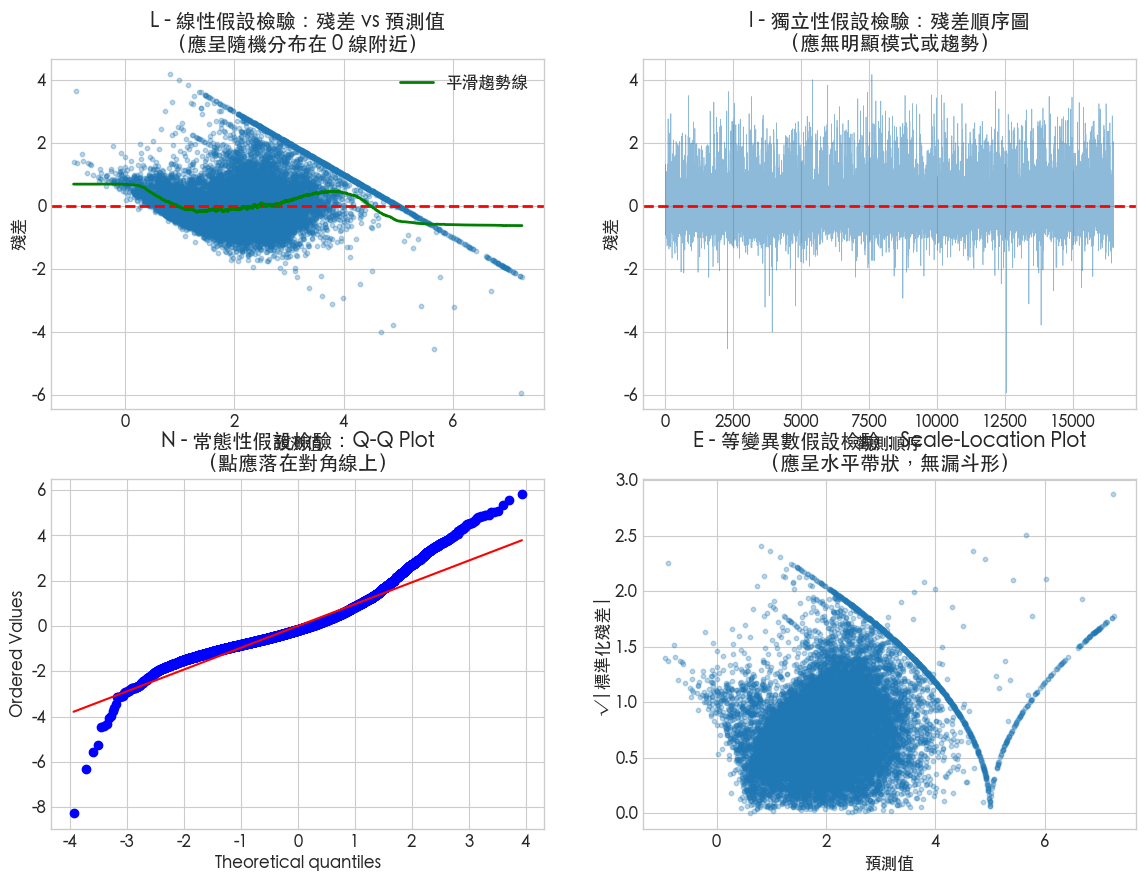

In [27]:
def check_regression_assumptions(y_true, y_pred, feature_name="Model"):
    """
    完整的迴歸假設檢驗視覺化
    檢驗 LINE 假設：線性、獨立、常態、等變異數
    """
    residuals = y_true - y_pred
    standardized_res = (residuals - residuals.mean()) / residuals.std()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 線性假設：殘差 vs 預測值
    axes[0, 0].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('預測值')
    axes[0, 0].set_ylabel('殘差')
    axes[0, 0].set_title('L - 線性假設檢驗：殘差 vs 預測值\n（應呈隨機分布在 0 線附近）')
    
    # 加入 LOWESS 平滑線
    from scipy.ndimage import uniform_filter1d
    sorted_idx = np.argsort(y_pred)
    y_pred_sorted = y_pred[sorted_idx]
    res_sorted = residuals.values[sorted_idx]
    smoothed = uniform_filter1d(res_sorted, size=500)
    axes[0, 0].plot(y_pred_sorted, smoothed, color='green', linewidth=2, label='平滑趨勢線')
    axes[0, 0].legend()
    
    # 2. 獨立假設：殘差順序圖
    axes[0, 1].plot(range(len(residuals)), residuals.values, alpha=0.5, linewidth=0.5)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('觀測順序')
    axes[0, 1].set_ylabel('殘差')
    axes[0, 1].set_title('I - 獨立性假設檢驗：殘差順序圖\n（應無明顯模式或趨勢）')
    
    # 3. 常態假設：Q-Q Plot
    stats.probplot(standardized_res, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('N - 常態性假設檢驗：Q-Q Plot\n（點應落在對角線上）')
    axes[1, 0].get_lines()[1].set_color('red')
    
    # 4. 等變異數假設：Scale-Location Plot
    sqrt_abs_res = np.sqrt(np.abs(standardized_res))
    axes[1, 1].scatter(y_pred, sqrt_abs_res, alpha=0.3, s=10)
    axes[1, 1].set_xlabel('預測值')
    axes[1, 1].set_ylabel('√|標準化殘差|')
    axes[1, 1].set_title('E - 等變異數假設檢驗：Scale-Location Plot\n（應呈水平帶狀，無漏斗形）')
    
    # 加入平滑線
    sorted_idx = np.argsort(y_pred)
    y_pred_sorted = y_pred[sorted_idx]
    sqrt_sorted = sqrt_abs_res[sorted_idx]
    smoothed = uniform_filter1d(sqrt_sorted, size=500)
    axes[1, 1].plot(y_pred_sorted, smoothed, color='red', linewidth=2, label='平滑趨勢線')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return residuals, standardized_res

residuals, std_residuals = check_regression_assumptions(y_train, y_train_pred)

In [28]:
# 統計檢定
print("假設檢驗統計結果")
print("=" * 50)

# 1. 常態性檢定（使用抽樣，因 Shapiro-Wilk 對大樣本敏感）
sample_size = min(5000, len(residuals))
sample_residuals = np.random.choice(residuals, size=sample_size, replace=False)
stat, p_value = shapiro(sample_residuals)
print(f"\n1. 常態性檢定 (Shapiro-Wilk):")
print(f"   統計量: {stat:.4f}")
print(f"   p-value: {p_value:.4f}")
print(f"   結論: {'殘差呈常態分布 ✓' if p_value > 0.05 else '殘差不呈常態分布 ✗'}")

# 2. 殘差偏態與峰態
from scipy.stats import skew, kurtosis
print(f"\n2. 殘差分布形狀:")
print(f"   偏態係數: {skew(residuals):.4f} (0 為對稱)")
print(f"   峰態係數: {kurtosis(residuals):.4f} (0 為常態)")

# 3. Durbin-Watson 檢定（獨立性）
def durbin_watson(residuals):
    """計算 Durbin-Watson 統計量"""
    diff = np.diff(residuals)
    dw = np.sum(diff**2) / np.sum(residuals**2)
    return dw

dw_stat = durbin_watson(residuals.values)
print(f"\n3. 獨立性檢定 (Durbin-Watson):")
print(f"   DW 統計量: {dw_stat:.4f}")
print(f"   解釋: DW ≈ 2 表示無自相關")
print(f"   結論: {'無明顯自相關 ✓' if 1.5 < dw_stat < 2.5 else '可能存在自相關 ✗'}")

假設檢驗統計結果

1. 常態性檢定 (Shapiro-Wilk):
   統計量: 0.9309
   p-value: 0.0000
   結論: 殘差不呈常態分布 ✗

2. 殘差分布形狀:
   偏態係數: 1.0706 (0 為對稱)
   峰態係數: 3.0061 (0 為常態)

3. 獨立性檢定 (Durbin-Watson):
   DW 統計量: 1.9618
   解釋: DW ≈ 2 表示無自相關
   結論: 無明顯自相關 ✓


### 假設檢驗結果解讀

根據上述圖表與統計檢定結果：

| 假設 | 檢驗方法 | 觀察結果 | 可能問題 |
|------|----------|----------|----------|
| **線性** | 殘差 vs 預測值圖 | 殘差在高預測值處偏離 0 | 可能需要非線性轉換 |
| **獨立** | Durbin-Watson | DW ≈ 2 | 基本符合 |
| **常態** | Q-Q Plot + Shapiro | 尾部偏離 | 大樣本下可接受 |
| **等變異數** | Scale-Location | 輕微漏斗形 | 可能存在異質變異數 |

**改進建議：**
1. 對目標變數進行對數轉換
2. 加入多項式特徵處理非線性
3. 移除或處理高影響力異常值

---
# Part 3: 實作 - 進階技術
---

## 3.1 模型診斷

除了假設檢驗外，我們還需要識別可能對模型產生不當影響的觀測值。

### 關鍵概念

| 概念 | 定義 | 識別方式 |
|------|------|----------|
| **Leverage（槓桿值）** | 觀測值在特徵空間中的極端程度 | $h_{ii}$ 值，高 = 特徵值異常 |
| **殘差（Residual）** | 預測誤差大小 | 標準化殘差 > 3 |
| **影響力（Influence）** | 對模型係數的影響程度 | Cook's Distance |

**高影響力點 = 高槓桿 + 高殘差**

In [ ]:
# 使用 statsmodels 進行完整模型診斷
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

# 建立 statsmodels 模型（需要加入常數項）
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# 獲取影響力診斷
influence = OLSInfluence(ols_model)

# 計算關鍵指標
leverage = influence.hat_matrix_diag  # 槓桿值
cooks_d = influence.cooks_distance[0]  # Cook's Distance
studentized_residuals = influence.resid_studentized_internal  # 學生化殘差

print("模型診斷統計量")
print("=" * 50)
print(f"槓桿值範圍: [{leverage.min():.4f}, {leverage.max():.4f}]")
print(f"Cook's D 範圍: [{cooks_d.min():.6f}, {cooks_d.max():.4f}]")
print(f"學生化殘差範圍: [{studentized_residuals.min():.2f}, {studentized_residuals.max():.2f}]")

In [ ]:
# 診斷圖
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cook's Distance
axes[0, 0].stem(range(len(cooks_d)), cooks_d, markerfmt=',', basefmt=' ')
threshold_cooks = 4 / len(y_train)  # 常用閾值
axes[0, 0].axhline(y=threshold_cooks, color='red', linestyle='--', 
                   label=f'閾值 (4/n = {threshold_cooks:.4f})')
axes[0, 0].set_xlabel('觀測值索引')
axes[0, 0].set_ylabel("Cook's Distance")
axes[0, 0].set_title("Cook's Distance：識別高影響力點")
axes[0, 0].legend()

# 2. Leverage vs 學生化殘差
axes[0, 1].scatter(leverage, studentized_residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=3, color='red', linestyle='--', alpha=0.7)
axes[0, 1].axhline(y=-3, color='red', linestyle='--', alpha=0.7)
threshold_leverage = 2 * (X_train.shape[1] + 1) / len(y_train)
axes[0, 1].axvline(x=threshold_leverage, color='green', linestyle='--', 
                   alpha=0.7, label=f'槓桿閾值 ({threshold_leverage:.4f})')
axes[0, 1].set_xlabel('Leverage（槓桿值）')
axes[0, 1].set_ylabel('學生化殘差')
axes[0, 1].set_title('Leverage vs 學生化殘差：四象限分析')
axes[0, 1].legend()

# 3. 槓桿值分布
axes[1, 0].hist(leverage, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=threshold_leverage, color='red', linestyle='--',
                   label=f'閾值 = {threshold_leverage:.4f}')
axes[1, 0].set_xlabel('Leverage（槓桿值）')
axes[1, 0].set_ylabel('頻率')
axes[1, 0].set_title('槓桿值分布')
axes[1, 0].legend()

# 4. Cook's Distance vs Leverage（氣泡圖）
sizes = np.abs(studentized_residuals) * 20
axes[1, 1].scatter(leverage, cooks_d, s=sizes, alpha=0.3)
axes[1, 1].axhline(y=threshold_cooks, color='red', linestyle='--', alpha=0.7)
axes[1, 1].axvline(x=threshold_leverage, color='green', linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('Leverage（槓桿值）')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's D vs Leverage（氣泡大小 = |殘差|）")

plt.tight_layout()
plt.show()

In [ ]:
# 識別問題觀測值
high_cooks = np.where(cooks_d > threshold_cooks)[0]
high_leverage = np.where(leverage > threshold_leverage)[0]
high_residual = np.where(np.abs(studentized_residuals) > 3)[0]

print("問題觀測值識別")
print("=" * 50)
print(f"高 Cook's Distance (>{threshold_cooks:.4f}): {len(high_cooks)} 個 ({100*len(high_cooks)/len(y_train):.1f}%)")
print(f"高槓桿值 (>{threshold_leverage:.4f}): {len(high_leverage)} 個 ({100*len(high_leverage)/len(y_train):.1f}%)")
print(f"高殘差 (|殘差|>3): {len(high_residual)} 個 ({100*len(high_residual)/len(y_train):.1f}%)")

# 同時滿足多個條件的點
influential = set(high_cooks) & set(high_leverage)
print(f"\n高影響力點（高 Cook's D + 高槓桿）: {len(influential)} 個")

## 3.2 異常值處理

### 異常值類型

| 類型 | 描述 | 處理建議 |
|------|------|----------|
| **資料錯誤** | 輸入錯誤、測量失誤 | 修正或移除 |
| **真實極端值** | 罕見但真實的觀測 | 謹慎處理，可能包含重要資訊 |
| **不同母體** | 來自不同分布的觀測 | 分開建模 |

### 處理策略

1. **移除**：確定為錯誤時使用
2. **截斷（Winsorization）**：將極端值限制在某百分位
3. **轉換**：對數轉換減少極端值影響
4. **穩健迴歸**：使用對異常值不敏感的方法

In [ ]:
# 異常值偵測方法比較
def detect_outliers_iqr(series, k=1.5):
    """使用 IQR 方法偵測異常值"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series, threshold=3):
    """使用 Z-score 方法偵測異常值"""
    z_scores = np.abs((series - series.mean()) / series.std())
    return z_scores > threshold

# 對目標變數進行異常值偵測
outliers_iqr = detect_outliers_iqr(y_train)
outliers_zscore = detect_outliers_zscore(y_train)

print("異常值偵測結果（目標變數）")
print("=" * 50)
print(f"IQR 方法: {outliers_iqr.sum()} 個異常值 ({100*outliers_iqr.mean():.1f}%)")
print(f"Z-score 方法: {outliers_zscore.sum()} 個異常值 ({100*outliers_zscore.mean():.1f}%)")

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IQR 方法
Q1, Q3 = y_train.quantile([0.25, 0.75])
IQR = Q3 - Q1
axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(Q1 - 1.5*IQR, color='red', linestyle='--', label='IQR 邊界')
axes[0].axvline(Q3 + 1.5*IQR, color='red', linestyle='--')
axes[0].set_title('IQR 方法異常值偵測')
axes[0].set_xlabel('MedHouseVal')
axes[0].legend()

# Z-score 方法
mean, std = y_train.mean(), y_train.std()
axes[1].hist(y_train, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(mean - 3*std, color='red', linestyle='--', label='±3σ 邊界')
axes[1].axvline(mean + 3*std, color='red', linestyle='--')
axes[1].set_title('Z-score 方法異常值偵測')
axes[1].set_xlabel('MedHouseVal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 移除高影響力點後的模型比較
# 使用 Cook's Distance 識別的高影響力點
mask_clean = cooks_d <= threshold_cooks

X_train_clean = X_train_scaled[mask_clean]
y_train_clean = y_train.iloc[mask_clean]

# 重新訓練模型
lr_clean = LinearRegression()
lr_clean.fit(X_train_clean, y_train_clean)

# 預測（使用原始測試集）
y_test_pred_clean = lr_clean.predict(X_test_scaled)

# 比較結果
print("移除高影響力點前後比較")
print("=" * 50)
print(f"移除樣本數: {(~mask_clean).sum()} ({100*(~mask_clean).mean():.1f}%)")
print(f"\n原始模型:")
print(f"  訓練 R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"  測試 R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"  測試 RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")

print(f"\n移除異常值後:")
print(f"  訓練 R²: {r2_score(y_train_clean, lr_clean.predict(X_train_clean)):.4f}")
print(f"  測試 R²: {r2_score(y_test, y_test_pred_clean):.4f}")
print(f"  測試 RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_clean)):.4f}")

## 3.3 特徵工程

特徵工程是提升模型效能的關鍵步驟。

### 常見技術

| 技術 | 適用場景 | 注意事項 |
|------|----------|----------|
| **多項式特徵** | 非線性關係 | 容易過擬合 |
| **對數轉換** | 右偏分布、乘法關係 | 需處理零值 |
| **交互作用項** | 特徵間有協同效應 | 增加複雜度 |
| **分箱（Binning）** | 非單調關係 | 損失資訊 |

In [ ]:
# 1. 多項式特徵
from sklearn.preprocessing import PolynomialFeatures

# 比較不同多項式次數
degrees = [1, 2, 3]
results = []

for degree in degrees:
    # 只對最重要的特徵做多項式展開（避免維度爆炸）
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train)
    
    y_train_pred_poly = lr_poly.predict(X_train_poly)
    y_test_pred_poly = lr_poly.predict(X_test_poly)
    
    results.append({
        '多項式次數': degree,
        '特徵數': X_train_poly.shape[1],
        '訓練 R²': r2_score(y_train, y_train_pred_poly),
        '測試 R²': r2_score(y_test, y_test_pred_poly),
        '測試 RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
    })

poly_df = pd.DataFrame(results)
print("多項式特徵比較")
print("=" * 60)
print(poly_df.to_string(index=False))

print("\n注意：高次多項式可能導致過擬合（訓練 R² 高，測試 R² 下降）")

In [ ]:
# 2. 對數轉換
# 對目標變數進行對數轉換（處理右偏分布）
y_train_log = np.log1p(y_train)  # log(1+x) 處理可能的零值
y_test_log = np.log1p(y_test)

# 訓練對數模型
lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)

# 預測並反轉換
y_test_pred_log = np.expm1(lr_log.predict(X_test_scaled))  # exp(x) - 1

print("對數轉換效果")
print("=" * 50)
print(f"原始模型測試 R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"對數轉換測試 R²: {r2_score(y_test, y_test_pred_log):.4f}")
print(f"原始模型測試 RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"對數轉換測試 RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_log)):.4f}")

# 視覺化轉換效果
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('原始目標變數分布')
axes[0].set_xlabel('MedHouseVal')

axes[1].hist(y_train_log, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('對數轉換後分布')
axes[1].set_xlabel('log(1 + MedHouseVal)')

plt.tight_layout()
plt.show()

In [ ]:
# 3. 交互作用項
# 手動建立有意義的交互作用項
X_train_interact = X_train.copy()
X_test_interact = X_test.copy()

# 建立交互作用項：收入 × 房齡（可能影響房價的組合）
X_train_interact['MedInc_x_HouseAge'] = X_train['MedInc'] * X_train['HouseAge']
X_test_interact['MedInc_x_HouseAge'] = X_test['MedInc'] * X_test['HouseAge']

# 建立：房間數 × 家庭成員（人均空間）
X_train_interact['Rooms_per_Person'] = X_train['AveRooms'] / (X_train['AveOccup'] + 0.1)
X_test_interact['Rooms_per_Person'] = X_test['AveRooms'] / (X_test['AveOccup'] + 0.1)

# 標準化
scaler_interact = StandardScaler()
X_train_interact_scaled = scaler_interact.fit_transform(X_train_interact)
X_test_interact_scaled = scaler_interact.transform(X_test_interact)

# 訓練模型
lr_interact = LinearRegression()
lr_interact.fit(X_train_interact_scaled, y_train)
y_test_pred_interact = lr_interact.predict(X_test_interact_scaled)

print("交互作用項效果")
print("=" * 50)
print(f"新增特徵: {list(X_train_interact.columns[-2:])}")
print(f"原始特徵數: {X_train.shape[1]}")
print(f"新特徵數: {X_train_interact.shape[1]}")
print(f"\n原始模型測試 R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"加入交互作用項測試 R²: {r2_score(y_test, y_test_pred_interact):.4f}")

## 3.4 特徵選擇

### 方法比較

| 方法 | 類型 | 優點 | 缺點 |
|------|------|------|------|
| **相關性篩選** | Filter | 快速、簡單 | 忽略特徵間關係 |
| **VIF** | Filter | 處理多重共線性 | 需設定閾值 |
| **前向選擇** | Wrapper | 考慮特徵組合 | 計算成本高 |
| **後向消除** | Wrapper | 從完整模型開始 | 初始模型可能不穩定 |
| **Lasso** | Embedded | 自動選擇 | 受正則化強度影響 |

In [ ]:
# VIF 計算
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X, feature_names):
    """計算各特徵的 VIF"""
    vif_data = pd.DataFrame()
    vif_data['特徵'] = feature_names
    vif_data['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

# 計算 VIF
vif_results = calculate_vif(X_train_scaled, X.columns.tolist())

print("VIF 分析（Variance Inflation Factor）")
print("=" * 50)
print("VIF 解讀：1 = 無共線性, 5-10 = 中度, >10 = 高度共線性\n")
print(vif_results.to_string(index=False))

# 視覺化
plt.figure(figsize=(10, 6))
colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in vif_results['VIF']]
plt.barh(vif_results['特徵'], vif_results['VIF'], color=colors, alpha=0.7)
plt.axvline(x=5, color='orange', linestyle='--', label='中度共線性閾值 (5)')
plt.axvline(x=10, color='red', linestyle='--', label='高度共線性閾值 (10)')
plt.xlabel('VIF')
plt.title('特徵 VIF 分析')
plt.legend()
plt.tight_layout()
plt.show()

## 3.5 交叉驗證

交叉驗證是評估模型泛化能力的重要技術。

### K-Fold 交叉驗證

將資料分成 K 份，每次用 K-1 份訓練，1 份驗證，重複 K 次。

**優點：**
- 充分利用所有資料
- 減少評估的變異性
- 更可靠的效能估計

**常見設定：** K = 5 或 10

In [ ]:
# K-Fold 交叉驗證
from sklearn.model_selection import cross_val_score, KFold

# 設定交叉驗證
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 評估不同指標
lr = LinearRegression()

# R² 分數
cv_r2 = cross_val_score(lr, X_train_scaled, y_train, cv=kfold, scoring='r2')

# 負 MSE（sklearn 使用負值以便最大化）
cv_mse = -cross_val_score(lr, X_train_scaled, y_train, cv=kfold, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(cv_mse)

# MAE
cv_mae = -cross_val_score(lr, X_train_scaled, y_train, cv=kfold, scoring='neg_mean_absolute_error')

print("5-Fold 交叉驗證結果")
print("=" * 60)
print(f"\nR² 分數:")
print(f"  各 Fold: {cv_r2.round(4)}")
print(f"  平均值: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

print(f"\nRMSE:")
print(f"  各 Fold: {cv_rmse.round(4)}")
print(f"  平均值: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

print(f"\nMAE:")
print(f"  各 Fold: {cv_mae.round(4)}")
print(f"  平均值: {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")

In [ ]:
# 學習曲線：診斷過擬合/欠擬合
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

# 計算平均值和標準差
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# 繪圖
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='訓練分數')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='驗證分數')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.1, color='green')

plt.xlabel('訓練樣本數')
plt.ylabel('R² 分數')
plt.title('學習曲線：診斷過擬合/欠擬合')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("學習曲線解讀：")
print("- 兩條曲線都低且接近：欠擬合（需要更複雜的模型）")
print("- 訓練高、驗證低且有差距：過擬合（需要更多資料或正則化）")
print("- 兩條曲線都高且收斂：良好的擬合")

## 3.6 正則化簡介

正則化是防止過擬合的重要技術，在損失函數中加入懲罰項限制係數大小。

### 三種主要方法

| 方法 | 懲罰項 | 特性 | 適用場景 |
|------|--------|------|----------|
| **Ridge (L2)** | $\\lambda \\sum \\beta_j^2$ | 係數縮小但不為零 | 多重共線性 |
| **Lasso (L1)** | $\\lambda \\sum \|\\beta_j\|$ | 可產生稀疏解 | 特徵選擇 |
| **ElasticNet** | 混合 L1 + L2 | 結合兩者優點 | 相關特徵群組 |

### 何時使用正則化？

1. **特徵數多於樣本數**（p > n）
2. **存在多重共線性**
3. **模型過擬合**（訓練好、測試差）
4. **需要特徵選擇**（使用 Lasso）

**詳細內容請參考：** `linear_regression.ipynb`

In [ ]:
# 快速正則化比較
from sklearn.linear_model import Ridge, Lasso

# 訓練模型
models = {
    'Linear': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1)
}

print("正則化效果快速比較")
print("=" * 60)

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # 計算非零係數數量（對 Lasso 有意義）
    n_nonzero = np.sum(model.coef_ != 0)
    
    results.append({
        '模型': name,
        '測試 R²': r2_score(y_test, y_pred),
        '測試 RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        '非零係數': n_nonzero,
        '係數範圍': f"[{model.coef_.min():.2f}, {model.coef_.max():.2f}]"
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\n更多正則化內容請參考 linear_regression.ipynb")

---
# Part 4: 面試問答
---

以下是 ML 面試中常見的迴歸相關問題，點擊展開查看答案。

### Q1: 線性迴歸有哪些假設？違反這些假設會有什麼後果？

<details>
<summary>點擊展開答案</summary>

**四大假設（LINE）：**

| 假設 | 內容 | 違反後果 |
|------|------|----------|
| **L**inearity | 自變數與應變數呈線性關係 | 係數估計有偏誤，預測不準確 |
| **I**ndependence | 觀測值相互獨立 | 標準誤估計不準，假設檢定無效 |
| **N**ormality | 殘差呈常態分布 | 信賴區間和 t 檢定不可靠 |
| **E**qual variance | 殘差變異數恆定 | 係數估計不再是最佳估計（BLUE） |

**重要觀念：**
- 違反線性假設最嚴重，因為係數本身就是錯的
- 常態性假設在大樣本下可放寬（中央極限定理）
- 違反等變異數不影響係數無偏性，但影響標準誤

**檢驗方法：**
- 線性：殘差 vs 預測值圖
- 獨立：Durbin-Watson 檢定
- 常態：Q-Q plot、Shapiro-Wilk 檢定
- 等變異數：Scale-Location plot、Breusch-Pagan 檢定
</details>

### Q2: R² 和 Adjusted R² 有什麼差異？何時該用哪個？

<details>
<summary>點擊展開答案</summary>

**R²（決定係數）：**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

**Adjusted R²：**
$$Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$

| 面向 | R² | Adjusted R² |
|------|-----|-------------|
| 特徵增加時 | 永遠增加或不變 | 可能下降 |
| 懲罰機制 | 無 | 對特徵數量懲罰 |
| 適用場景 | 單一模型評估 | 比較不同特徵數的模型 |

**關鍵差異：**
- R² 的問題：加入任何特徵（即使無關）都會增加 R²
- Adjusted R² 會對無用特徵進行懲罰
- 當加入的特徵沒有足夠解釋力時，Adjusted R² 會下降

**使用建議：**
- 比較不同模型時，使用 Adjusted R²
- 報告模型效能時，兩者都報告
- 特徵數相同時，兩者結論一致
</details>

### Q3: MSE 和 MAE 有什麼差異？什麼時候選擇哪個？

<details>
<summary>點擊展開答案</summary>

**公式：**
- MSE: $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$
- MAE: $\frac{1}{n}\sum|y_i - \hat{y}_i|$

| 特性 | MSE | MAE |
|------|-----|-----|
| 對大誤差敏感度 | 高（平方放大） | 低（線性） |
| 對異常值穩健性 | 差 | 好 |
| 可微分性 | 處處可微 | 在 0 點不可微 |
| 單位 | 原單位的平方 | 與原單位相同 |
| 優化難度 | 較易（凸且平滑） | 較難 |

**選擇指南：**

| 場景 | 建議 | 原因 |
|------|------|------|
| 大誤差代價很高 | MSE/RMSE | 平方懲罰大誤差 |
| 資料有異常值 | MAE | 不會被極端值主導 |
| 需要梯度優化 | MSE | 處處可微 |
| 業務報告 | MAE/RMSE | 單位直觀 |
| 誤差分布對稱 | MSE | 最小化方差 |
| 誤差分布有偏 | MAE | 最小化中位數誤差 |

**面試技巧：** 說明選擇理由比選擇本身更重要。
</details>

### Q4: 什麼是多重共線性？它如何影響模型？如何處理？

<details>
<summary>點擊展開答案</summary>

**定義：** 自變數之間存在高度線性相關。

**影響：**

| 影響 | 說明 |
|------|------|
| 係數不穩定 | 小幅資料變動導致係數大幅改變 |
| 標準誤膨脹 | 難以判斷個別特徵的顯著性 |
| 解釋困難 | 無法分離個別特徵的貢獻 |
| 矩陣近似奇異 | $(X^TX)^{-1}$ 計算不穩定 |

**重要觀念：** 多重共線性**不影響預測能力**，只影響係數解釋。

**偵測方法：**
1. 相關性矩陣：|r| > 0.8 需注意
2. VIF > 10：高度共線性
3. 條件數（Condition Number）> 30：矩陣接近奇異

**處理方法：**

| 方法 | 適用場景 |
|------|----------|
| 移除特徵 | 確定哪個特徵較不重要 |
| PCA | 需要保留所有資訊 |
| Ridge 迴歸 | 需要預測但也想解釋 |
| 特徵組合 | 特徵有業務意義可合併 |
</details>

### Q5: 如何解釋迴歸係數？標準化和未標準化係數有何不同？

<details>
<summary>點擊展開答案</summary>

**未標準化係數：**
> 「在其他變數不變的情況下，X 每增加一單位，Y 預期改變 β 單位。」

- 係數單位 = Y 單位 / X 單位
- 不同特徵的係數**不能直接比較**（單位不同）

**標準化係數：**
> 「在其他變數不變的情況下，X 每增加一個標準差，Y 預期改變 β 個標準差。」

- 所有係數都是無單位的
- 可以直接比較**特徵重要性**

**比較：**

| 面向 | 未標準化 | 標準化 |
|------|----------|--------|
| 解釋性 | 業務意義清楚 | 相對重要性清楚 |
| 可比性 | 不可直接比較 | 可直接比較 |
| 單位 | 有單位 | 無單位 |
| 使用場景 | 解釋效果大小 | 比較特徵重要性 |

**注意事項：**
1. 多重共線性下，係數解釋不可靠
2. 「其他變數不變」可能不現實（特徵相關時）
3. 相關性 ≠ 因果關係
</details>

### Q6: 如何進行殘差分析？應該看哪些圖？

<details>
<summary>點擊展開答案</summary>

**殘差分析四大圖：**

| 圖表 | 檢驗內容 | 理想狀態 | 問題徵兆 |
|------|----------|----------|----------|
| 殘差 vs 預測值 | 線性、等變異數 | 隨機散布在 0 附近 | 曲線模式、漏斗形 |
| Q-Q Plot | 常態性 | 點落在對角線上 | 尾部偏離 |
| Scale-Location | 等變異數 | 水平帶狀 | 上升或下降趨勢 |
| 殘差 vs 順序 | 獨立性 | 無趨勢或週期 | 有規律波動 |

**常見問題模式：**

1. **U 形或倒 U 形曲線**
   - 問題：違反線性假設
   - 解決：加入多項式項或變數轉換

2. **漏斗形（扇形）**
   - 問題：異質變異數
   - 解決：對數轉換或 WLS

3. **尾部偏離 Q-Q 線**
   - 問題：殘差非常態
   - 解決：Box-Cox 轉換或移除異常值

4. **有規律波動**
   - 問題：自相關（常見於時間序列）
   - 解決：加入滯後項或使用時間序列模型
</details>

### Q7: 異常值如何影響線性迴歸？應該如何處理？

<details>
<summary>點擊展開答案</summary>

**異常值類型：**

| 類型 | 描述 | 影響 |
|------|------|------|
| 高殘差點 | Y 值異常 | 拉動迴歸線 |
| 高槓桿點 | X 值異常 | 可能大幅改變斜率 |
| 高影響力點 | 兩者皆高 | 對模型影響最大 |

**OLS 對異常值敏感的原因：**
- 最小化**平方**誤差，大誤差影響被放大
- 一個極端點可能完全改變迴歸線方向

**識別方法：**
1. **Cook's Distance > 4/n**：高影響力點
2. **Leverage > 2(p+1)/n**：高槓桿點
3. **|標準化殘差| > 3**：高殘差點

**處理策略：**

| 策略 | 適用情況 |
|------|----------|
| 移除 | 確定是資料錯誤 |
| 保留 | 真實但罕見的觀測 |
| Winsorization | 將極端值限制在某百分位 |
| 穩健迴歸 | Huber、RANSAC 等方法 |
| 分開建模 | 異常值來自不同母體 |

**重要原則：** 先調查異常值的原因，再決定處理方式。盲目移除可能損失重要資訊。
</details>

### Q8: 特徵縮放（Feature Scaling）何時是必要的？

<details>
<summary>點擊展開答案</summary>

**必要的情況：**

| 場景 | 原因 |
|------|------|
| **正則化迴歸** | 懲罰項對係數大小敏感，需公平比較 |
| **梯度下降** | 不同尺度導致收斂緩慢 |
| **比較係數重要性** | 標準化後係數可直接比較 |
| **PCA** | 大尺度特徵主導主成分 |

**不必要的情況：**

| 場景 | 原因 |
|------|------|
| **純線性迴歸** | 不影響預測結果（只影響係數值） |
| **樹模型** | 基於分割點，對尺度不敏感 |
| **需要原始單位解釋** | 標準化後失去業務意義 |

**常見方法：**

| 方法 | 公式 | 適用場景 |
|------|------|----------|
| StandardScaler | $(x - \mu) / \sigma$ | 常態分布資料 |
| MinMaxScaler | $(x - min) / (max - min)$ | 有界限的資料 |
| RobustScaler | $(x - median) / IQR$ | 有異常值的資料 |

**重要提醒：**
- 只用訓練集 fit，再 transform 測試集
- 避免資料洩漏
</details>

### Q9: 如何辨識過擬合和欠擬合？

<details>
<summary>點擊展開答案</summary>

**診斷表：**

| 指標 | 欠擬合 | 良好擬合 | 過擬合 |
|------|--------|----------|--------|
| 訓練誤差 | 高 | 低 | 很低 |
| 驗證誤差 | 高 | 低 | 高 |
| 訓練-驗證差距 | 小 | 小 | 大 |
| 模型複雜度 | 太簡單 | 適中 | 太複雜 |

**學習曲線診斷：**

```
欠擬合：          良好擬合：         過擬合：
Error             Error             Error
  |                 |                 |
  |---訓練          |  ----訓練        |----訓練
  |---驗證          |  ----驗證        |
  |                 |                 |----驗證
  +--------→       +--------→        +--------→
    樣本數           樣本數             樣本數
```

**解決方法：**

| 問題 | 解決方案 |
|------|----------|
| **欠擬合** | 增加模型複雜度、加入更多特徵、減少正則化、多項式特徵 |
| **過擬合** | 增加資料量、減少特徵、增加正則化、交叉驗證、Early stopping |

**Bias-Variance 觀點：**
- 欠擬合 = 高偏差（High Bias）
- 過擬合 = 高變異（High Variance）
</details>

### Q10: 為什麼交叉驗證很重要？什麼時候該用什麼類型的 CV？

<details>
<summary>點擊展開答案</summary>

**交叉驗證的重要性：**

1. **更可靠的效能估計**：減少單次切分的隨機性
2. **充分利用資料**：所有資料都被用於訓練和驗證
3. **檢測過擬合**：比較訓練和驗證分數的穩定性
4. **模型選擇**：公平比較不同模型

**CV 類型選擇：**

| 類型 | 適用場景 | 注意事項 |
|------|----------|----------|
| **K-Fold** | 一般情況 | K=5 或 10 常用 |
| **Stratified K-Fold** | 分類任務、不平衡資料 | 保持類別比例 |
| **Leave-One-Out** | 小資料集 | 計算成本高 |
| **Time Series Split** | 時間序列資料 | 保持時間順序 |
| **Group K-Fold** | 有群組結構的資料 | 同群組不跨切分 |

**時間序列特別注意：**
- **不能**用普通 K-Fold（會有未來資料洩漏）
- 必須用 TimeSeriesSplit 或 expanding/sliding window

**K 值選擇：**
- K 太小：估計偏差大
- K 太大：計算成本高、估計變異大
- 常用 K=5（偏差-變異平衡較好）
</details>

### Q11: 多項式迴歸有什麼風險？

<details>
<summary>點擊展開答案</summary>

**多項式迴歸：** $y = \beta_0 + \beta_1 x + \beta_2 x^2 + ... + \beta_d x^d$

**風險與問題：**

| 風險 | 說明 |
|------|------|
| **過擬合** | 高次項容易擬合雜訊 |
| **維度爆炸** | 特徵數隨次數指數增長 |
| **數值不穩定** | 高次項數值可能極大或極小 |
| **外推危險** | 在訓練範圍外預測極不可靠 |
| **多重共線性** | $x$, $x^2$, $x^3$ 高度相關 |

**特徵數增長：**
- 2 個特徵，2 次：$\binom{2+2}{2} = 6$ 個
- 5 個特徵，3 次：$\binom{5+3}{3} = 56$ 個
- 10 個特徵，3 次：$\binom{10+3}{3} = 286$ 個

**最佳實踐：**

1. **限制次數**：通常 2-3 次就夠
2. **搭配正則化**：Ridge 或 Lasso
3. **交叉驗證選擇次數**
4. **標準化特徵**：避免數值問題
5. **考慮其他非線性方法**：樣條、GAM、樹模型
</details>

### Q12: 什麼情況下線性迴歸不適用？

<details>
<summary>點擊展開答案</summary>

**不適用的情況：**

| 情況 | 原因 | 替代方案 |
|------|------|----------|
| **非線性關係** | 違反線性假設 | 多項式迴歸、樹模型、神經網路 |
| **分類問題** | 目標是類別 | 邏輯迴歸、SVM、樹模型 |
| **極端異常值** | OLS 對異常值敏感 | 穩健迴歸、分位數迴歸 |
| **高維小樣本** | p >> n 時矩陣不可逆 | 正則化、PCA |
| **時間序列** | 違反獨立性 | ARIMA、VAR |
| **目標有界** | 預測可能超出範圍 | GLM、對數轉換 |
| **計數資料** | 非負整數目標 | 泊松迴歸 |
| **生存分析** | 有截斷/設限資料 | Cox 迴歸 |

**如何判斷：**

1. **畫散佈圖**：觀察是否呈線性關係
2. **檢查殘差圖**：是否有系統性模式
3. **了解業務邏輯**：關係是否合理為線性
4. **嘗試非線性模型**：比較效能

**記住：** 線性迴歸是基準模型（baseline），理解它的局限才能選擇更好的模型。
</details>

### Q13: 梯度下降和正規方程式有什麼差異？什麼時候用哪個？

<details>
<summary>點擊展開答案</summary>

**正規方程式：** $\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^Ty$

**梯度下降：** $\boldsymbol{\beta}_{t+1} = \boldsymbol{\beta}_t - \alpha \nabla L$

**比較：**

| 面向 | 正規方程式 | 梯度下降 |
|------|------------|----------|
| 解的類型 | 精確解 | 近似解 |
| 時間複雜度 | O(p³) | O(kp²)，k=迭代次數 |
| 超參數 | 無 | 學習率、迭代次數 |
| 記憶體 | 需儲存 X^TX | 可用 mini-batch |
| 特徵數 p | 小於 10,000 適用 | 任意大小 |
| 矩陣可逆性 | 需要 X^TX 可逆 | 不需要 |

**選擇指南：**

| 場景 | 建議 |
|------|------|
| 特徵數 < 10,000 | 正規方程式（精確、快速） |
| 特徵數 > 10,000 | 梯度下降 |
| 串流/在線學習 | 隨機梯度下降 |
| 有多重共線性 | 梯度下降 + 正則化 |
| 需要快速原型 | sklearn 預設（自動選擇） |

**sklearn 實作：**
- `LinearRegression`：小資料用正規方程式
- `SGDRegressor`：隨機梯度下降
</details>

### Q14: 有哪些特徵選擇方法？如何比較它們？

<details>
<summary>點擊展開答案</summary>

**三大類方法：**

| 類型 | 方法 | 優點 | 缺點 |
|------|------|------|------|
| **Filter** | 相關性、VIF、互資訊 | 快速、獨立於模型 | 忽略特徵交互 |
| **Wrapper** | 前向選擇、後向消除、RFE | 考慮特徵組合 | 計算成本高 |
| **Embedded** | Lasso、Ridge、樹模型 | 訓練中自動選擇 | 依賴特定模型 |

**常用方法詳解：**

**1. 相關性篩選**
- 移除與目標相關性低的特徵
- 簡單但忽略非線性關係

**2. VIF（變異膨脹因子）**
- 處理多重共線性
- VIF > 10 考慮移除

**3. 前向選擇（Forward Selection）**
- 從空模型開始，逐步加入最佳特徵
- 適合特徵數較少時

**4. 後向消除（Backward Elimination）**
- 從完整模型開始，逐步移除最差特徵
- 適合樣本數大於特徵數時

**5. Lasso（L1 正則化）**
- 自動將不重要特徵係數設為 0
- 高維資料的首選

**選擇建議：**
- 探索階段：Filter 方法快速篩選
- 建模階段：Lasso 或 RFE
- 最終驗證：Wrapper 方法（如計算資源允許）
</details>

### Q15: 部署迴歸模型時有哪些注意事項？

<details>
<summary>點擊展開答案</summary>

**部署前檢查清單：**

| 階段 | 檢查項目 |
|------|----------|
| **資料** | 訓練/生產資料分布是否一致？ |
| **前處理** | Scaler、Encoder 是否保存並正確套用？ |
| **效能** | 延遲和吞吐量是否符合需求？ |
| **監控** | 預測分布、輸入分布是否有漂移？ |

**常見問題與解決：**

**1. 資料漂移（Data Drift）**
- 問題：生產資料分布與訓練時不同
- 解決：定期監控、觸發重新訓練

**2. 前處理不一致**
- 問題：訓練和推論時的 scaling 參數不同
- 解決：保存完整 pipeline（含 scaler）

**3. 缺失值處理**
- 問題：生產環境出現訓練時沒見過的缺失
- 解決：建立健全的缺失值處理邏輯

**4. 新類別值**
- 問題：類別特徵出現新值
- 解決：Unknown category 處理、定期更新編碼器

**5. 極端預測值**
- 問題：預測值超出合理範圍
- 解決：加入輸出範圍限制（clipping）

**監控指標：**
- 預測分布（均值、標準差、百分位）
- 特徵分布變化
- 預測延遲
- 錯誤率

**最佳實踐：**
```python
# 保存完整 pipeline
import joblib
joblib.dump(pipeline, 'model_pipeline.pkl')

# 載入時包含所有前處理
pipeline = joblib.load('model_pipeline.pkl')
predictions = pipeline.predict(new_data)
```
</details>

---
# Part 5: 總結
---

## 本筆記本涵蓋內容

### 理論基礎
- 迴歸概述與類型
- 簡單/多元線性迴歸數學推導
- 四大假設（LINE）及其檢驗方法
- 評估指標（MSE、RMSE、MAE、R²、Adjusted R²）
- 多重共線性與 VIF

### 實作技能
- California Housing 資料集 EDA
- 假設檢驗視覺化與統計檢定
- Cook's Distance、Leverage 模型診斷
- 異常值偵測與處理策略
- 特徵工程（多項式、對數轉換、交互作用項）
- 交叉驗證與學習曲線

### 面試準備
- 15 道常見面試題與詳細解答
- 涵蓋理論、實作、診斷、部署等面向

## 關鍵要點

| 主題 | 重點 |
|------|------|
| **假設檢驗** | LINE 缺一不可，殘差圖是最佳診斷工具 |
| **多重共線性** | 影響解釋不影響預測，VIF > 10 需處理 |
| **異常值** | 先調查原因再決定處理方式 |
| **特徵縮放** | 正則化和梯度下降必須，純 OLS 非必須 |
| **交叉驗證** | 時間序列不能用普通 K-Fold |
| **模型選擇** | R² 會騙人，用 Adjusted R² 比較 |

## 延伸閱讀

- **正則化技術**：請參考 `linear_regression.ipynb`
- **時間序列迴歸**：請參考 `time_series/` 系列筆記本
- **進階診斷**：statsmodels 官方文檔

## 實用資源

```python
# 快速建立完整迴歸分析流程
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# 交叉驗證評估
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print(f"CV R²: {scores.mean():.4f} ± {scores.std():.4f}")
```

---
**祝面試順利！**